# Summarization

This notebook investigates whether summarizing job descriptions improves or hurts
classification performance compared to using the full original text.

**Hypothesis:** Job descriptions contain boilerplate, legal text, and repetitive phrasing
that may dilute the signal for classification. Summarization could strip that noise and
retain only the discriminative content as well as optimize the pipeline.

**Plan:**
1. Summarize `description` with three summarizers — TextRank (statistical/extractive),
   DistilBART and T5 base (both deep-learning/abstractive). The summaries are generated by
   `src/models/serve/summarize.py` and **precomputed** to `data/precomputed/summarization/`; this
   notebook loads them rather than re-running the models.
2. Compare summary quality: lengths and compression vs the originals.
3. Evaluate downstream classification: accuracy, MAE, and F1 macro/weighted across the
   original text and all three summary variants.

Evaluation uses 2,000 rows drawn from the v5 **test** split (held-out rows the model never
trained on), with cross-validated predictions so every row gets an out-of-fold prediction
and we compare on the full subset.

## 1. Imports and Setup

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import textwrap
from tqdm import tqdm

warnings.filterwarnings('ignore')
tqdm.pandas()

pd.set_option('display.max_colwidth', 200)

SEED = 42
np.random.seed(SEED)
%matplotlib inline

## 2. Configuration

Set paths and parameters here. Change `TARGET_COL` to match your classification target.

In [81]:
# ---- paths ----
DATA_PATH = '../data/processed/cleaned_job_postings.csv'

# Precomputed summaries (generated by src/models/serve/summarize.py). text_rank stores
# the summary in a `description` column; the abstractive files keep both the
# original `description` and the generated `summary`.
O_TEXTRANK_PATH = '../data/precomputed/summarization/text_rank_summaries.csv'
O_BART_PATH     = '../data/precomputed/summarization/bart_job_summaries.csv'
O_T5_PATH       = '../data/precomputed/summarization/t5_job_summaries.csv'

# Precomputed BERT domain similarities for each text variant (job_id, domain_sim_*).
O_TEXTRANK_DOMAIN_PATH = '../data/precomputed/summarization/text_rank_domain_probabilities.csv'
O_BART_DOMAIN_PATH     = '../data/precomputed/summarization/bart_domain_probabilities.csv'
O_T5_DOMAIN_PATH       = '../data/precomputed/summarization/t5_domain_probabilities.csv'

# v5 holds the train/test split AND keeps job_id, so we use the test split's
# job_ids to restrict this experiment to held-out rows only.
V5_TEST_PATH = '../data/processed/v5/feature_matrix_test.csv'


# ---- target for downstream classification ----
TARGET_COL = 'formatted_experience_level'   # change to your classification target

# ---- sampling ----
N_ROWS = 2_000

# ---- summarization params ----
TEXTRANK_SENTENCES = 3       # how many sentences the extractive summary keeps

## 3. Data Preparation

In [82]:
df_full = pd.read_csv(DATA_PATH)
print(f'Full dataset: {df_full.shape}')
print(f'Description nulls: {df_full["description"].isna().sum()}')
print(f'Target nulls:      {df_full[TARGET_COL].isna().sum()}')

Full dataset: (123545, 24)
Description nulls: 7
Target nulls:      29345


In [83]:
# keep only rows that have both description and target
df_valid = df_full.dropna(subset=['description', TARGET_COL]).copy()
print(f'Rows with both description and target: {len(df_valid):,}')

# restrict to the v5 TEST split so we never evaluate on rows the model trained on
test_job_ids = pd.read_csv(V5_TEST_PATH, usecols=['job_id'])['job_id']
df_valid = df_valid[df_valid['job_id'].isin(test_job_ids)].copy()
print(f'Rows also in v5 test split: {len(df_valid):,}')

# sample N_ROWS
df = df_valid.sample(n=N_ROWS, random_state=SEED).reset_index(drop=True)
print(f'Sampled {len(df):,} rows')
print(f'\nTarget distribution:\n{df[TARGET_COL].value_counts()}')

Rows with both description and target: 94,200
Rows also in v5 test split: 18,856
Sampled 2,000 rows

Target distribution:
formatted_experience_level
Mid-Senior level    862
Entry level         784
Associate           219
Director             76
Executive            33
Internship           26
Name: count, dtype: int64


Description length (words):
count    2000.0
mean      539.0
std       296.0
min        18.0
25%       326.0
50%       492.0
75%       709.0
max      2258.0
Name: desc_len_words, dtype: float64


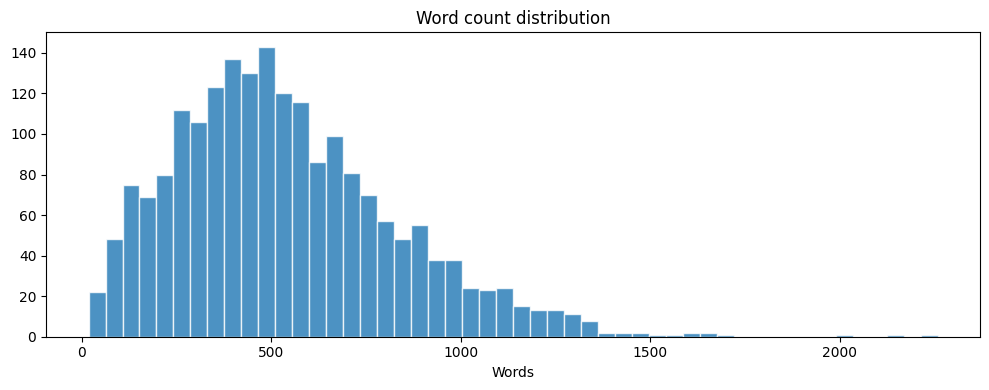

In [84]:
# description length stats
df['desc_len_chars'] = df['description'].str.len()
df['desc_len_words'] = df['description'].str.split().str.len()

print('Description length (words):')
print(df['desc_len_words'].describe().round(0))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['desc_len_words'], bins=50, edgecolor='white', alpha=0.8)
ax.set_title('Word count distribution')
ax.set_xlabel('Words')
plt.tight_layout()
plt.show()

## 4. Statistical Summarization (Extractive) - TextRank

TextRank builds a graph of sentences connected by similarity, then runs a
PageRank-like algorithm to identify the most central sentences.
The output is a subset of original sentences, not newly generated text.

> All three summaries (TextRank, DistilBART, T5) are generated by
> `src/models/serve/summarize.py` (`textrank_summarize_df` / `distilbart_summarize_df` /
> `t5_summarize_df`) and **precomputed** to `data/precomputed/summarization/`. The
> abstractive models are expensive, so this notebook **loads** the precomputed CSVs
> rather than re-running any model.


In [85]:
# load precomputed TextRank summaries (job_id, description=summary)
textrank_df = pd.read_csv(O_TEXTRANK_PATH)
df_tr = df[['job_id', 'description']].merge(
    textrank_df.rename(columns={'description': 'summary_extractive'}),
    on='job_id', how='left',
)
print(f'Loaded {len(textrank_df):,} TextRank summaries')

# sanity check on one row: original vs summary
print('ORIGINAL (first 500 chars):')
print(df_tr['description'].iloc[0][:500])
print(f'\n--- ({len(df_tr["description"].iloc[0])} chars) ---\n')
print('TEXTRANK SUMMARY:')
print(df_tr['summary_extractive'].iloc[0][:500])
print(f'\n--- ({len(df_tr["summary_extractive"].iloc[0])} chars) ---')

Loaded 2,000 TextRank summaries
ORIGINAL (first 500 chars):
duties

summary

the nasa office of inspector general (oig) conducts audits, reviews, and investigations of nasa programs and operations to prevent and detect fraud, waste, abuse, and mismanagement and to assist nasa management in promoting economy, efficiency, and effectiveness. the oig consists of auditors, analysts, specialists, investigators, attorneys, and support staff at nasa headquarters in washington, dc and nasa centers throughout the united states.

requirements

qualifications

minim

--- (3906 chars) ---

TEXTRANK SUMMARY:
the nasa office of inspector general (oig) conducts audits, reviews, and investigations of nasa programs and operations to prevent and detect fraud, waste, abuse, and mismanagement and to assist nasa management in promoting economy, efficiency, and effectiveness. specialized experience is experience that has equipped you with the particular ability, skill, and knowledge to successfully perform t

TextRank summary length (words):
count    2000.0
mean      191.0
std       105.0
min        12.0
25%       113.0
50%       166.0
75%       247.0
max       803.0
Name: summary_extractive, dtype: float64


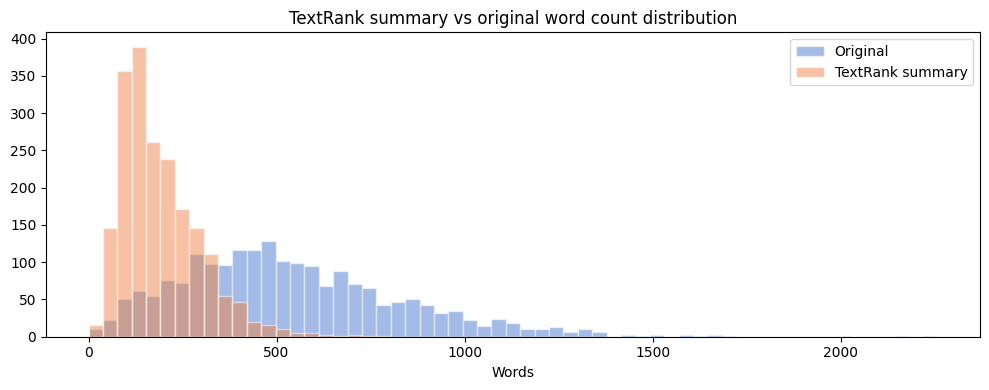

In [86]:
# TextRank summary length stats
tr_len_words = df_tr['summary_extractive'].str.split().str.len()

print('TextRank summary length (words):')
print(tr_len_words.describe().round(0))

# overlay original vs summary on shared bins so the compression is visible
bins = np.linspace(0, max(df['desc_len_words'].max(), tr_len_words.max()), 60)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['desc_len_words'], bins=bins, alpha=0.5, color='#4878CF',
        edgecolor='white', label='Original')
ax.hist(tr_len_words, bins=bins, alpha=0.5, color='#EE854A',
        edgecolor='white', label='TextRank summary')
ax.set_title('TextRank summary vs original word count distribution')
ax.set_xlabel('Words')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Deep Learning DistilBART (Abstractive)

DistilBART (`sshleifer/distilbart-cnn-12-6`) generates a *new* condensed summary rather
than extracting sentences. Summaries are precomputed by
`src.models.serve.summarize.distilbart_summarize_df` and loaded here.

Loaded 2,000 DistilBART summaries
ORIGINAL (first 500 chars):
duties

summary

the nasa office of inspector general (oig) conducts audits, reviews, and investigations of nasa programs and operations to prevent and detect fraud, waste, abuse, and mismanagement and to assist nasa management in promoting economy, efficiency, and effectiveness. the oig consists of auditors, analysts, specialists, investigators, attorneys, and support staff at nasa headquarters in washington, dc and nasa centers throughout the united states.

requirements

qualifications

minim

--- (3906 chars) ---

DISTILBART SUMMARY:
 The nasa office of inspector general (oig) conducts audits, reviews, and investigations of nasa programs and operations to prevent and detect fraud, waste, and mismanagement . The oig consists of auditors, analysts, specialists, investigators, and support staff .

--- (264 chars) ---

DistilBART summary length (words):
count    2000.0
mean       41.0
std         7.0
min        16.0
25%     

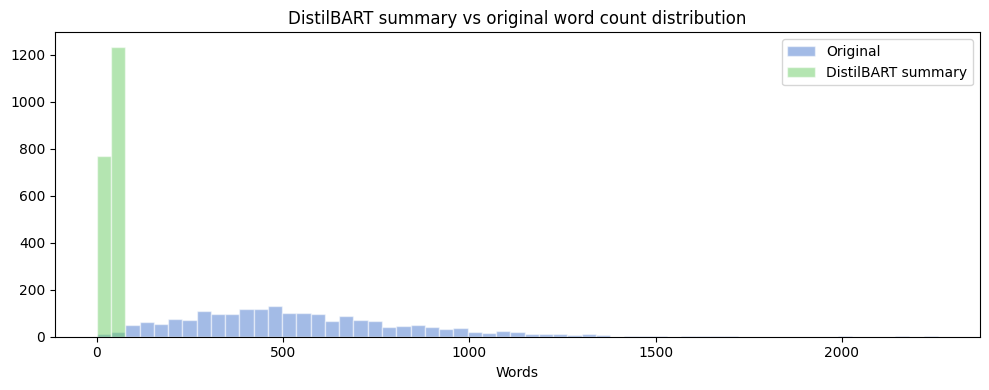

In [87]:
# load precomputed DistilBART summaries (job_id, description, summary)
df_bart = pd.read_csv(O_BART_PATH)
print(f'Loaded {len(df_bart):,} DistilBART summaries')

# sanity check on one row: original vs summary
print('ORIGINAL (first 500 chars):')
print(df_bart['description'].iloc[0][:500])
print(f'\n--- ({len(df_bart["description"].iloc[0])} chars) ---\n')
print('DISTILBART SUMMARY:')
print(df_bart['summary'].iloc[0][:500])
print(f'\n--- ({len(df_bart["summary"].iloc[0])} chars) ---')

# summary length stats
bart_len_words = df_bart['summary'].str.split().str.len()
print('\nDistilBART summary length (words):')
print(bart_len_words.describe().round(0))

# overlay original vs summary on shared bins so the compression is visible
bins = np.linspace(0, max(df['desc_len_words'].max(), bart_len_words.max()), 60)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['desc_len_words'], bins=bins, alpha=0.5, color='#4878CF',
        edgecolor='white', label='Original')
ax.hist(bart_len_words, bins=bins, alpha=0.5, color='#6ACC64',
        edgecolor='white', label='DistilBART summary')
ax.set_title('DistilBART summary vs original word count distribution')
ax.set_xlabel('Words')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Deep Learning T5 base (Abstractive)

T5 base (`t5-base`, with the `"summarize: "` task prefix) is a second abstractive
summarizer. Summaries are precomputed by `src.models.serve.summarize.t5_summarize_df` and
loaded here.

Loaded 2,000 T5 summaries
ORIGINAL (first 500 chars):
duties

summary

the nasa office of inspector general (oig) conducts audits, reviews, and investigations of nasa programs and operations to prevent and detect fraud, waste, abuse, and mismanagement and to assist nasa management in promoting economy, efficiency, and effectiveness. the oig consists of auditors, analysts, specialists, investigators, attorneys, and support staff at nasa headquarters in washington, dc and nasa centers throughout the united states.

requirements

qualifications

minim

--- (3906 chars) ---

T5 SUMMARY:
oig conducts audits, reviews, and investigations of nasa programs and operations. specialized experience is experience that has equipped you with the particular ability, skill, and knowledge to successfully perform the duties of this position. to qualify for gs-14, you must have one year of directly related specialised experience.

--- (332 chars) ---

T5 summary length (words):
count    2000.0
mean       4

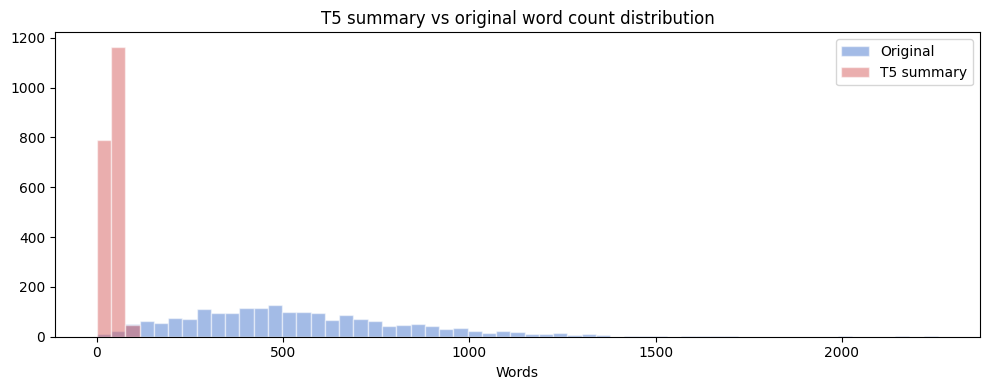

In [88]:
# load precomputed T5 summaries (job_id, description, summary)
df_t5 = pd.read_csv(O_T5_PATH)
print(f'Loaded {len(df_t5):,} T5 summaries')

# sanity check on one row: original vs summary
print('ORIGINAL (first 500 chars):')
print(df_t5['description'].iloc[0][:500])
print(f'\n--- ({len(df_t5["description"].iloc[0])} chars) ---\n')
print('T5 SUMMARY:')
print(df_t5['summary'].iloc[0][:500])
print(f'\n--- ({len(df_t5["summary"].iloc[0])} chars) ---')

# summary length stats
t5_len_words = df_t5['summary'].str.split().str.len()
print('\nT5 summary length (words):')
print(t5_len_words.describe().round(0))

# overlay original vs summary on shared bins so the compression is visible
bins = np.linspace(0, max(df['desc_len_words'].max(), t5_len_words.max()), 60)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['desc_len_words'], bins=bins, alpha=0.5, color='#4878CF',
        edgecolor='white', label='Original')
ax.hist(t5_len_words, bins=bins, alpha=0.5, color='#D65F5F',
        edgecolor='white', label='T5 summary')
ax.set_title('T5 summary vs original word count distribution')
ax.set_xlabel('Words')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Downstream Evaluation - Classification

The core experiment. Instead of a throwaway TF-IDF classifier, we evaluate against the
**actual deployed model** — the Optuna-tuned LightGBM logged to MLflow — using the project's
real feature pipeline (`run_pipeline.prepare_data`) and inference entry point
(`run_classification`).

We compare four datasets that differ **only** in the `description` text:
- **baseline** — original descriptions
- **TextRank** — extractive summaries (section 4)
- **DistilBART** — abstractive summaries (section 5)
- **T5** — abstractive summaries (section 6)

Each is pushed through `prepare_data` → `run_classification`, then predictions are scored
against the true `experience_level_ord` with the canonical metrics in
`src/utils/evaluation.py` (accuracy, MAE, F1 macro/weighted).

Because the description flows into the salary regex, the domain embeddings, and
`desc_word_count`, any metric delta is attributable to summarization alone. The expensive
BERT **domain classification is precomputed** for every variant (one
`*_domain_probabilities.csv` per variant) and fed straight into the pipeline, so the
notebook never re-embeds the postings.

In [89]:
# ---- imports / path setup ----
# prepare_data and run_classification are cwd-independent (repo-root-anchored
# paths + package imports), so we only need the repo root on sys.path -- no chdir.
import sys
import os

REPO_ROOT = os.path.abspath('..')          # notebook lives in notebooks/
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from src.data.run_pipeline import prepare_data
from src.utils.evaluation import (
    compute_metrics,
    evaluate_model,
    compare_models,
    plot_model_comparison,
)
from src.models.serve.classification import run_classification

print('cwd:', os.getcwd())

cwd: c:\Users\ognjen.vujovic\Desktop\job-intelligence\job-intelligence\notebooks


In [90]:
# ---- build the four inference inputs from RAW postings ----
# prepare_data expects the raw postings schema (data/raw/postings.csv) and re-cleans
# internally. Every variant shares all columns except `description`.
raw     = pd.read_csv(os.path.join(REPO_ROOT, 'data', 'raw', 'postings.csv'))
raw_20k = raw[raw['job_id'].isin(df['job_id'])].reset_index(drop=True)
print(f'Baseline raw postings: {raw_20k.shape}')


def swap_description(summary_df, summary_col):
    """Swap raw `description` for a precomputed summary, joined on job_id."""
    summaries = summary_df[['job_id', summary_col]].rename(columns={summary_col: 'description'})
    return (
        raw_20k.drop(columns=['description'])
               .merge(summaries, on='job_id', how='inner')
    )


# text_rank stores the summary in its `description` column; bart/t5 in `summary`.
raw_textrank = swap_description(pd.read_csv(O_TEXTRANK_PATH), 'description')
raw_bart     = swap_description(df_bart, 'summary')
raw_t5       = swap_description(df_t5, 'summary')
print(f'TextRank: {raw_textrank.shape} | DistilBART: {raw_bart.shape} | T5: {raw_t5.shape}')

# ---- precomputed domain similarities (job_id, domain_sim_*) ----
# baseline: subset of the full whole-dataset file; summaries: their own files.
domain_base     = pd.read_csv(os.path.join(REPO_ROOT, 'data', 'precomputed', 'domain_probabilities.csv'))
domain_textrank = pd.read_csv(os.path.join(REPO_ROOT, O_TEXTRANK_DOMAIN_PATH.lstrip('./')))
domain_bart     = pd.read_csv(os.path.join(REPO_ROOT, O_BART_DOMAIN_PATH.lstrip('./')))
domain_t5       = pd.read_csv(os.path.join(REPO_ROOT, O_T5_DOMAIN_PATH.lstrip('./')))
print(
    f'Domain shapes -> baseline: {domain_base.shape} | TextRank: {domain_textrank.shape} | '
    f'DistilBART: {domain_bart.shape} | T5: {domain_t5.shape}'
)

Baseline raw postings: (2000, 31)
TextRank: (2000, 31) | DistilBART: (2000, 31) | T5: (2000, 31)
Domain shapes -> baseline: (123545, 14) | TextRank: (20000, 14) | DistilBART: (2000, 14) | T5: (2000, 14)


In [91]:
BASELINE = 'baseline (original)'
variants = {
    BASELINE:                (raw_20k,      domain_base),
    'summarized (TextRank)':  (raw_textrank, domain_textrank),
    'summarized (DistilBART)':(raw_bart,     domain_bart),
    'summarized (T5)':        (raw_t5,       domain_t5),
}

feature_matrices = {}
for name, (raw_df, dom_df) in variants.items():
    print(f'\n{"=" * 60}\n{name} -- prepare_data\n{"=" * 60}')
    feature_matrices[name] = prepare_data(raw_df, domain_df=dom_df, verbose=False)

baseline_wc = feature_matrices[BASELINE]['desc_word_count']
for name in feature_matrices:
    if name != BASELINE:
        feature_matrices[name]['desc_word_count'] = baseline_wc.values

print('\nFeature matrices ready.')


baseline (original) -- prepare_data


Extracting salaries from descriptions:   0%|          | 0/2000 [00:00<?, ?it/s]


summarized (TextRank) -- prepare_data


Extracting salaries from descriptions:   0%|          | 0/2000 [00:00<?, ?it/s]


summarized (DistilBART) -- prepare_data


Extracting salaries from descriptions:   0%|          | 0/2000 [00:00<?, ?it/s]


summarized (T5) -- prepare_data


Extracting salaries from descriptions:   0%|          | 0/2000 [00:01<?, ?it/s]


Feature matrices ready.


In [92]:
# ---- classify + score each variant ----
metrics_by_variant = {}
preds_by_variant = {}

total_variants = len(feature_matrices)
for idx, (name, fm) in enumerate(feature_matrices.items(), start=1):
    print(f'{name} -- classification ({idx} out of {total_variants})')
    
    pred = run_classification(fm, verbose=False)

    scored = pred.dropna(subset=['experience_level_ord'])
    y_true = scored['experience_level_ord'].astype(int)
    y_pred = scored['predicted_experience_level_ord'].astype(int)

    metrics_by_variant[name] = compute_metrics(y_true, y_pred)
    preds_by_variant[name] = (y_true, y_pred)
    
print('\nDone.')

baseline (original) -- classification (1 out of 4)
summarized (TextRank) -- classification (2 out of 4)
summarized (DistilBART) -- classification (3 out of 4)
summarized (T5) -- classification (4 out of 4)

Done.


### Visualizing the comparison

The tables above as plots. All four variants run through an identical pipeline and differ
**only** in the `description` text, so every gap is attributable to summarization alone.

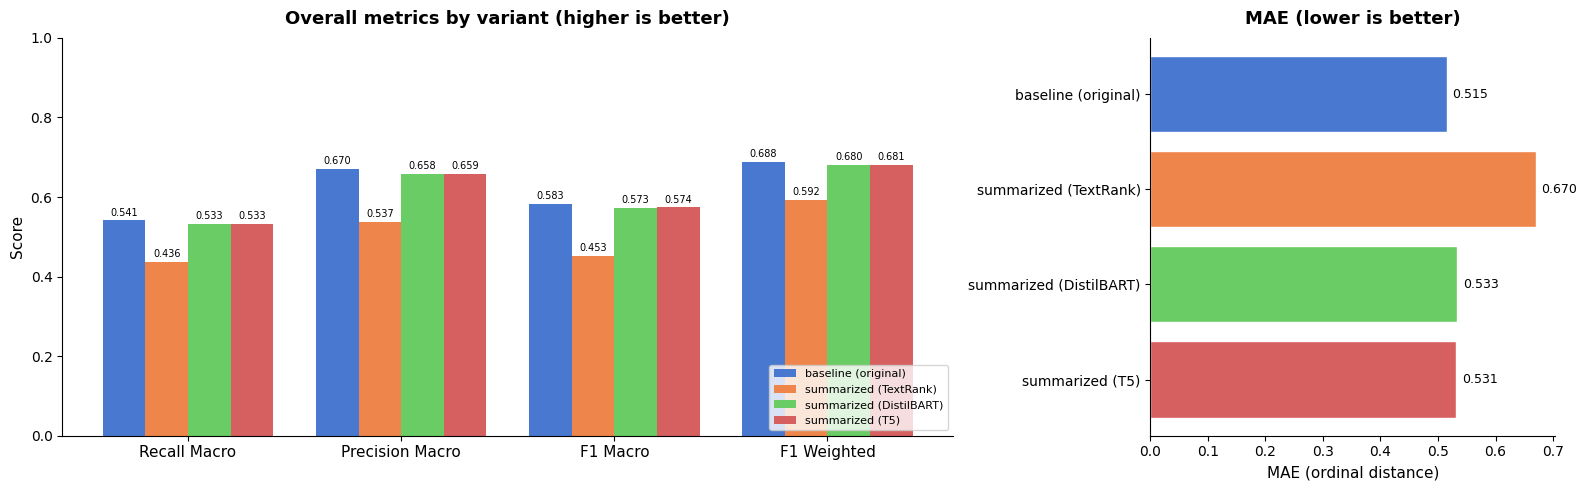

In [93]:
# -- Shared plotting setup ------------------------------------
from src.utils.evaluation import EXPERIENCE_LABELS

variant_names = list(metrics_by_variant.keys())            # baseline + 3 summarizers
class_names = [EXPERIENCE_LABELS[i] for i in sorted(EXPERIENCE_LABELS.keys())]
palette = ["#4878CF", "#EE854A", "#6ACC64", "#D65F5F"]     # one colour per variant

# -- Overall metrics (left) + ordinal MAE (right) -------------
# Macro precision/recall are the headline metrics here: the classes are heavily
# imbalanced, so accuracy is misleading and is dropped in favour of them.
metrics_to_plot = ["recall_macro", "precision_macro", "f1_macro", "f1_weighted"]
metric_labels = ["Recall Macro", "Precision Macro", "F1 Macro", "F1 Weighted"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [2.2, 1]})

x = np.arange(len(metrics_to_plot))
width = 0.2
for i, name in enumerate(variant_names):
    vals = [metrics_by_variant[name].get(m, 0) for m in metrics_to_plot]
    bars = ax1.bar(x + i * width, vals, width, label=name, color=palette[i % len(palette)])
    ax1.bar_label(bars, fmt="%.3f", fontsize=7, padding=2)
ax1.set_xticks(x + width * (len(variant_names) - 1) / 2)
ax1.set_xticklabels(metric_labels, fontsize=11)
ax1.set_ylim(0, 1.0)
ax1.set_ylabel("Score", fontsize=11)
ax1.set_title("Overall metrics by variant (higher is better)", fontsize=13, fontweight="bold", pad=10)
ax1.legend(loc="lower right", fontsize=8)
ax1.spines[["top", "right"]].set_visible(False)

mae_vals = [metrics_by_variant[name].get("mae", 0) for name in variant_names]
bars = ax2.barh(variant_names, mae_vals, color=palette[:len(variant_names)], edgecolor="white")
ax2.bar_label(bars, fmt="%.3f", fontsize=9, padding=4)
ax2.set_xlabel("MAE (ordinal distance)", fontsize=11)
ax2.set_title("MAE (lower is better)", fontsize=13, fontweight="bold", pad=10)
ax2.invert_yaxis()
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

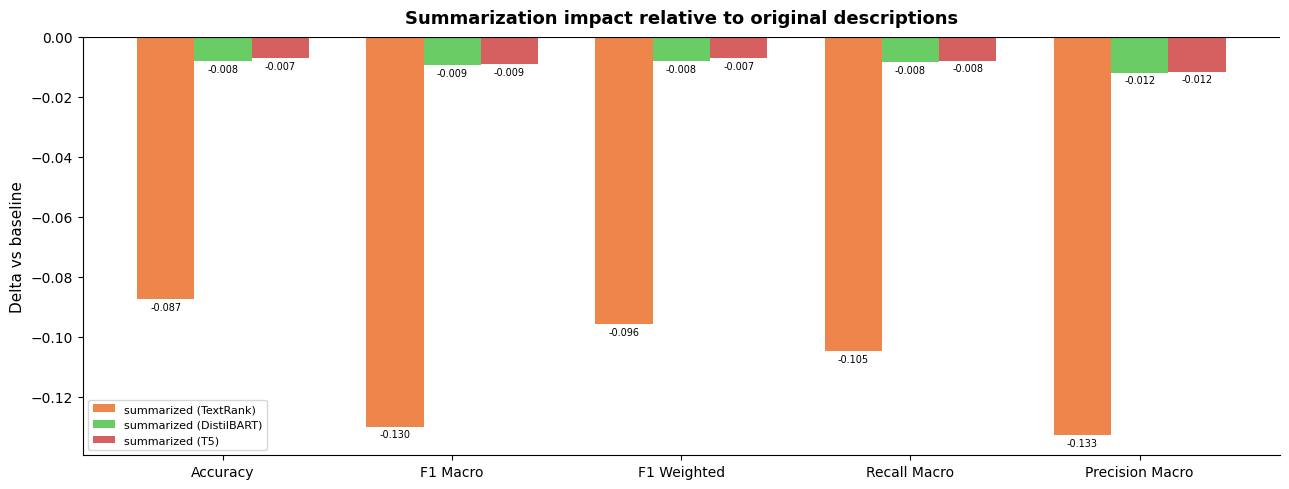

In [94]:
# -- Improvement over baseline --------------------------------
# Positive = the summary beats the original description on that metric. MAE is
# left out here (lower-is-better lives in the bar above) so every bar reads the
# same direction: up is good.
delta_metrics = ["accuracy", "f1_macro", "f1_weighted", "recall_macro", "precision_macro"]
delta_labels = ["Accuracy", "F1 Macro", "F1 Weighted", "Recall Macro", "Precision Macro"]
others = [n for n in variant_names if n != BASELINE]

fig, ax = plt.subplots(figsize=(13, 5))
xd = np.arange(len(delta_metrics))
wd = 0.25
for i, name in enumerate(others):
    deltas = [
        metrics_by_variant[name].get(m, 0) - metrics_by_variant[BASELINE].get(m, 0)
        for m in delta_metrics
    ]
    bars = ax.bar(xd + i * wd, deltas, wd, label=name, color=palette[(i + 1) % len(palette)])
    ax.bar_label(bars, fmt="%+.3f", fontsize=7, padding=2)

ax.set_xticks(xd + wd * (len(others) - 1) / 2)
ax.set_xticklabels(delta_labels, fontsize=10)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Delta vs baseline", fontsize=11)
ax.set_title("Summarization impact relative to original descriptions",
             fontsize=13, fontweight="bold", pad=10)
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()